#  Анализ рынка общественного питания Москвы
Автор: Ельцова Анастасия

### Цели и задачи проекта

**Цель:** Провести исследовательский анализ рынка заведений общественного питания Москвы для выбора подходящего места для открытия нового заведения.   

**Задачи:**
1. Загрузить данные и познакомиться с их содержимым.
2. Провести предобработку данных.
3. Провести исследовательский анализ данных:
    - изучить данные более детально;
    - изучить взаимосвязь данных между собой.
4. Сформулировать выводы по проведённому анализу.

### Описание данных

Для анализа поступили данные заведений общественного питания Москвы. Данные состоят из двух датасетов:
- `rest_info` - иноформация о заведениях общественного питания;
- `rest_price` - информация о среднем чеке в заведениях общественного питания.

#### Описание датасета `rest_info`
- `name` — название заведения;
- `address` — адрес заведения;
- `district` — административный район, в котором находится заведение;
- `category` — категория заведения;
- `hours` — информация о днях и часах работы;
- `rating` — рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка — 5.0);
- `chain` — является ли заведение сетевым:
    - 0 — заведение не является сетевым;
    - 1 — заведение является сетевым.
- `seats` — количество посадочных мест.

#### Описание датасета `rest_price`
- `price` — категория цен в заведении;
- `avg_bill` — строка, которая хранит среднюю стоимость заказа в виде диапазона;
- `middle_avg_bill` — число с оценкой среднего чека, которое указано только для значений из столбца `avg_bill`, начинающихся с подстроки «Средний счёт»:
    - Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
    - Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
    - Если значения нет или оно не начинается с подстроки «Средний счёт», то в столбец ничего не войдёт.
- `middle_coffee_cup` — число с оценкой одной чашки капучино, которое указано только для значений из столбца `avg_bill`, начинающихся с подстроки «Цена одной чашки капучино»:
    - Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
    - Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
    - Если значения нет или оно не начинается с подстроки «Цена одной чашки капучино», то в столбец ничего не войдёт.

### Содержимое проекта

1. Загрузка данных и знакомство с ними.
2. Предобработка данных.
3. Исследовательский анализ данных.
4. Итоговые выводы и рекомендации.

## 1. Загрузка данных и знакомство с ними
Загрузим данные о заведениях общественного питания Москвы.

In [1]:
# Импортируем библиотеки
import pandas as pd

#Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

#Загружаем библиотеку для расчёта коэффициента корреляции phi_k
from phik import phik_matrix

In [2]:
# Загружаем данные в переменные rest_info и rest_price
rest_info = pd.read_csv('https://code._____.csv')
rest_price = pd.read_csv('https://code._____.csv')

Познакомимся с данными датасета `rest_info` - выведем первые, последние и случайные строки и информацию о датасете

In [3]:
# Выводим первые 5 строк
rest_info.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [4]:
# Выводим последние 5 строк
rest_info.tail()

,id,name,category,address,district,hours,rating,chain,seats
8401,0342ad1a45ed41ba89dcba246a8267e5,Суши Мания,кафе,"Москва, Профсоюзная улица, 56",Юго-Западный административный округ,"ежедневно, 09:00–02:00",4.4,0,86.0
8402,ee6bb7c3650e47bd8186fca08eda1091,Миславнес,кафе,"Москва, Пролетарский проспект, 19, корп. 1",Южный административный округ,"ежедневно, 08:00–22:00",4.8,0,150.0
8403,62e8c64d4c89467aba608e39ef87616b,Самовар,кафе,"Москва, Люблинская улица, 112А, стр. 1",Юго-Восточный административный округ,"ежедневно, круглосуточно",3.9,0,150.0
8404,06a0db5ecd4842d48cd6350aa923e297,Чайхана Sabr,кафе,"Москва, Люблинская улица, 112А, стр. 1",Юго-Восточный административный округ,"ежедневно, круглосуточно",4.2,1,150.0
8405,9d56f8f7a7f74df1a925bc0fd2de8aae,Kebab Time,кафе,"Москва, Россошанский проезд, 6",Южный административный округ,"ежедневно, круглосуточно",3.9,0,12.0


In [5]:
# Выводим 5 случайных строк
rest_info.sample(n=5)

,id,name,category,address,district,hours,rating,chain,seats
5464,ad0b3c0ada904db6b675a47ca6bb984c,Ирина 554,булочная,"Москва, Электродная улица, 2, стр. 1",Восточный административный округ,"ежедневно, 09:00–20:00",4.4,0,50.0
2036,0456cd553c0844c798b8c678ef7ac38e,Сусеки,кофейня,"Москва, улица Авиаконструктора Сухого, 2, корп. 1",Северный административный округ,"ежедневно, 08:30–21:30",4.3,1,NaN
4957,9a3816dfbb034fc1ae5b9a2e442aedbf,One Special,кофейня,"Москва, Павелецкая площадь, 3",Центральный административный округ,"ежедневно, 10:00–22:00",4.9,1,100.0
2497,e590b51fee9c4b75b11617277715a6c7,Fishop,быстрое питание,"Москва, Нижняя Красносельская улица, 35, стр. 59",Центральный административный округ,NaN,3.7,0,250.0
780,33d1eff8fe774296856e65e624d5ad86,Аладдин-Системс,кафе,"Москва, Гостиничная улица, 9",Северо-Восточный административный округ,NaN,3.3,0,125.0


In [6]:
# Выводим информацию о датасете
rest_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


---
Датасет `rest_info` содержит 9 столбцов и 8406 строк, в которых представлена информация о заведениях общественного питания Москвы. 

После первичного анализа данных можно сделать следующие выводы:
- Названия столбцов указаны в едином регистре и не требуют преобразования.
- Представленные данные содержат числовые и строковые данные.
    - Числовые данные (столбцы `rating`, `chain` и `seats`)  хранятся в типах данных `float64` и `int64`. Размерность этих данных можно оптимизировать, так как `rating` имеет значение до 5.0, `chain` имеет бинарный признак (1 или 0), `seats` количество посадочных мест, явно не имеет очень большого значения.
- Строковые данные хранятся в верном типе данных.
- Пропуски содержатся в столбах:
    - `hours` (информация о днях и часах работы) - возможно информация отсутствуте или некорректно загрузилась.
    - `seats` (количество посадочных мест) - возможно это заведения, которые работают только на вынос и в них не предусмотрены посадочные места.
- Значения в столбцах соответствуют своему описанию.
---

Теперь познакомимся с данными датасета `rest_price`

In [7]:
# Выводим первые 5 строк
rest_price.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [8]:
# Выводим последние 5 строк
rest_price.tail()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
4053,962800540173458486f3c465437c2d8b,средние,Цена бокала пива:от 140 ₽,NaN,NaN
4054,4277890d659341848d7051cbf2e51f51,выше среднего,Средний счёт:1000–1500 ₽,1250.0,NaN
4055,026cbc478f9b4c3294a83458dcd89982,средние,NaN,NaN,NaN
4056,71cc394927204d45b81c3a91edb47955,NaN,Средний счёт:50–250 ₽,150.0,NaN
4057,62e8c64d4c89467aba608e39ef87616b,NaN,Средний счёт:от 150 ₽,150.0,NaN


In [9]:
# Выводим 5 случайных строк
rest_price.sample(n=5)

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
2823,75d2b8e830164091840d3e40c8afa2a4,выше среднего,Средний счёт:1000–1500 ₽,1250.0,NaN
1136,5153f15da2964a668a5d4f0ec257e975,NaN,Средний счёт:250–350 ₽,300.0,NaN
1160,2e0d21db66a84c17a41996427f92bff0,низкие,Цена чашки капучино:100–140 ₽,NaN,120.0
2248,a06285b89d4f4e23ace4093632eace40,высокие,Средний счёт:1500–2000 ₽,1750.0,NaN
1643,90b88b113c1f45b98ac09fee4d9888b3,высокие,Средний счёт:2500–3000 ₽,2750.0,NaN


In [10]:
# Выводим информацию о датасете
rest_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


---
Датасет `rest_price` содержит 5 столбцов и 4058 строк, в которых представлена информация о среднем чеке в заведениях общественного питания Москвы.

После первичного анализа данных можно сделать следующие выводы:

- Названия столбцов указаны в едином регистре и не требуют преобразования.
- Представленные данные содержат числовые и строковые данные.
    - Числовые данные (столбцы `middle_avg_bill` и `middle_coffee_cup`) хранятся в типах данных `float64`. Размерность этих данных можно оптимизировать, так как они не имеют очень большого значения.
    - Строковые данные хранятся в верном типе данных.
- Пропуски содержатся в столбах:
    - `price` (категория цен в аведении) - возможно информация отсутствуте или некорректно загрузилась.
    - `avg_bill` (диапазон средней стоимости заказа) - возможно информация отсутствуте или некорректно загрузилась.
    - `middle_avg_bill` (средняя стоимость заказа из столбца `avg_bill`).
    - `middle_coffee_cup` (средняя стоимость одной чашки капучино из столбца `avg_bill`).

- Значения в столбцах соответствуют своему описанию.

---

### Промежуточный вывод

Первичное знакомство с данными показывает, что данные хорошего качества, хотя в них присутствует большое количество пропусков, сами данные соответствуют описанию и выглядят корректными.

В обоих датасетах присутствует столбец `id` с уникальными идентификаторами заведений. По этому столбцу произведем объединение датасетов.

---

## Подготовка единого датасета

Объединим данные двух датасетов так, чтобы осталась информация о всех заведениях.

In [11]:
# Соединяем данные в единый датасет
df = rest_info.merge (rest_price, on = 'id', how = 'left')

In [12]:
# Выводим информацию о датасете
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 853.9+ KB


---
Данные соединены, информация о всех заведениях сохранилась.

---

## 2. Предобработка данных

Преобразуем тип данных столбцов `rating`, `chain`, `seats`, `middle_avg_bill` и `middle_coffee_cup`

In [13]:
# Оптимизируем вещественные типы данных
for column in ['rating', 'seats', 'middle_avg_bill','middle_coffee_cup']:
    df[column] = pd.to_numeric(df[column],
                               downcast = 'float')

# Оптимизируем целочисленный тип данных столбца `chain`
df['chain'] = pd.to_numeric(df['chain'], downcast = 'integer')

In [14]:
# Проверим типы данных в датасете
df.dtypes

id                    object
name                  object
category              object
address               object
district              object
hours                 object
rating               float32
chain                   int8
seats                float32
price                 object
avg_bill              object
middle_avg_bill      float32
middle_coffee_cup    float32
dtype: object

---
Типы данных были успешно оптимизированы с понижением размерности.

---

#### Изучаем пропуски в данных

При первичном анализе мы обнаружили пропуски в столбцах `hours`, `seats`, `price`, `avg_bill`, `middle_avg_bill` и `middle_coffee_cup`. 
Узнаем абсолютное и относительное количество пропусков в этих столбцах.

In [15]:
# Выводим количество пропущенных строк  в каждом столбце в абсолютных и относительных значениях
missing_percentage = round(df.isna().sum() / len(df) * 100,2) 
missing_df = pd.DataFrame({
    'Количество пропусков': df.isna().sum(),
    'Доля пропущенных значений': df.isna().mean(),
    'Процент пропусков (%)': missing_percentage
})
print("\nАнализ пропущенных значений:")
display(missing_df)


Анализ пропущенных значений:


,Количество пропусков,Доля пропущенных значений,Процент пропусков (%)
id,0,0.000000,0.00
name,0,0.000000,0.00
category,0,0.000000,0.00
address,0,0.000000,0.00
district,0,0.000000,0.00
hours,536,0.063764,6.38
rating,0,0.000000,0.00
chain,0,0.000000,0.00
seats,3611,0.429574,42.96
price,5091,0.605639,60.56


---
В столбцах датасета обнаружены следующие значения пропусков:
- в столбце `hours` 536 пропусков или 6% данных - могут быть вызваны отсутсвием информации или с некорректной загрузкой данных.
- в столбце `seats` 3611 пропусков или 42% данных - могут означать отсутсвие посадочных мест, так как заведение работает только навынос. 
- в столбе `price` 5091 пропуск или 60% данных - данные могут отсутсвовать, так как содержат категории цен в заведении. Их могли просто не оценивать.
- в столбце `avg_bill` 4590 пропусков или 54% данных - данные могут отсутсвовать, так как это столбец содержит информационные данные о конкретных диапазонах цен на позиции из меню или диапазоне счета.
- в столбце `middle_avg_bill` 5257 пропусков или 62% данных. Содержит данные на основе столбца `avg_bill`, поэтому напрямую зависит от него.
- в столбце `middle_coffee_cup` 7871 пропуск или 93% данных. Содержит данные на основе столбца `avg_bill`, поэтому напрямую зависит от него.

Количество пропусков достаточно большое, чтобы просто их удалить.
Пропуски в столбце `hours` изучим дополнительно и удалим, так как информация о графике работы понадобится нам в дальнейшей работе.
Остальные пропуски оставим без изменения.

---

In [16]:
# Проверяем данные `hours` на уникальные значения
unique_hours = df['hours'].sort_values().unique()
print(f'Уникальные значения hours:')
unique_hours

Уникальные значения hours:


array(['Нет информации',
       'вт 08:30–17:00; ср,чт 12:00–20:30; пт 08:30–17:00; сб 09:00–16:30',
       'вт 13:00–21:00; ср 11:00–20:00; чт 13:00–21:00; пт-вс 11:00–20:00',
       ..., 'чт круглосуточно, перерыв 10:00–20:00; сб круглосуточно',
       'чт-вс 20:00–06:00', nan], dtype=object)

---
Так как в данных столбце `hours` больше 6% пропусков, оставим данные без изменения, чтобы не потерять данные в других столбцах.

---

Проверим данные на наличие неявных дубликатов

In [17]:
# Отсортируем датасет по всем столбцам
df_sorted = df.sort_values(by=df.columns.tolist())

In [18]:
# Ищем неявные дубликаты по названию заведения и адресу
df['name'] = df['name'].str.upper().str.strip()
df['address'] = df['address'].str.upper().str.strip()

duplicates = df.duplicated(subset = ['name', 'address'], keep = False)
num_duplicates = duplicates.sum()
print(f"Найдено дубликатов (название + адрес): {num_duplicates}")

Найдено дубликатов (название + адрес): 8


---
Обнаружно 8 неявных дубликатов. Удалим их.

---

In [19]:
# Удаляем дубликаты и нумеруем строки заново
df = df.drop_duplicates(subset = ['name', 'address']).reset_index(drop=True)

In [20]:
# Выводим информацию о датасете
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8402 entries, 0 to 8401
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8402 non-null   object 
 1   name               8402 non-null   object 
 2   category           8402 non-null   object 
 3   address            8402 non-null   object 
 4   district           8402 non-null   object 
 5   hours              7867 non-null   object 
 6   rating             8402 non-null   float32
 7   chain              8402 non-null   int8   
 8   seats              4792 non-null   float32
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float32
 12  middle_coffee_cup  535 non-null    float32
dtypes: float32(4), int8(1), object(8)
memory usage: 664.7+ KB


---
Неявные дубликаты удалены.

---

In [21]:
# Ищем дубликаты
duplicates = df[df.duplicated()].sum()
print(f'Дублирующиеся строки: {duplicates}')

Дублирующиеся строки: id                     0
name                   0
category               0
address                0
district               0
hours                  0
rating               0.0
chain                  0
seats                0.0
price                  0
avg_bill               0
middle_avg_bill      0.0
middle_coffee_cup    0.0
dtype: object


---
Явных дубликатов не обнаружено.

---

Для дальнейшей работы создадим столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7:
  - `True` — если заведение работает ежедневно и круглосуточно;
  - `False` — в противоположном случае.

In [22]:
# Создадим функцию для нового столбца is_24_7
def is_24_7 (hours):
    if hours == 'ежедневно, круглосуточно':
        return True
    return False

In [23]:
# Создадим новый столбец с помощью функции is_24_7
df['is_24_7'] = df['hours'].apply(is_24_7)

In [24]:
# Выведем случайные 5 строк для проверки
df.sample(n=5)

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,is_24_7
6617,fc796f27eb0044fe8ffce5f163a7c538,FRESH CAFE,кофейня,"МОСКВА, ЛЕНИНСКИЙ ПРОСПЕКТ, 119А",Юго-Западный административный округ,пн-пт 09:00–18:00,4.0,0,NaN,средние,Средний счёт:250 ₽,250.0,NaN,False
6399,896c030cf75f4996b4ca422340e4df89,SWEET LIFE,кафе,"МОСКВА, ВОЛГОГРАДСКИЙ ПРОСПЕКТ, 43, КОРП. 3",Юго-Восточный административный округ,NaN,4.2,0,100.0,NaN,NaN,NaN,NaN,False
6075,571419b78a5a409bbcc81425bbbac57a,ЛЮБИМЫЙ ГОРОД,кафе,"МОСКВА, УЛИЦА КЕДРОВА, 8, КОРП. 2",Юго-Западный административный округ,"ежедневно, 12:00–22:00",4.1,0,90.0,выше среднего,Средний счёт:1000–1500 ₽,1250.0,NaN,False
2037,8951444e04bc4eab98cb92b7d74b9ea0,СТАНЦИЯ ПЕЛЬМЕННАЯ,"бар,паб","МОСКВА, НОВОСЛОБОДСКАЯ УЛИЦА, 14/19С4",Центральный административный округ,"ежедневно, 11:00–22:00",4.3,0,NaN,средние,Цена бокала пива:100–250 ₽,NaN,NaN,False
2287,dc1aa9060280447198e68071790453a5,АКВАФОРТУНА,"бар,паб","МОСКВА, НОВОМОСКОВСКАЯ УЛИЦА, 24",Северо-Восточный административный округ,"ежедневно, круглосуточно",4.4,0,48.0,NaN,NaN,NaN,NaN,True


---
Столбец `is_24_7` успешно добавлен в датасет.

---

### Промежуточный вывод

Представленные данные хорошего качества, однако требовали немного действий по преобработке.

В результате предобработки данных были выполнены следующие действия:
- Оптимизированы тип данных числовых столбцов с понижением размерности.
- Изучены пропуски в данных. Пропуски были обнаружены в столбцах:
  - `hours` (6% данных), `seats` (43% данных), `price` (60% данных), `avg_bill` (54% данных), `middle_avg_bill` (62% данных) и `middle_coffee_cup` (93% данных).
- Выявлены и удалены неявные дубликаты по названию заведения и адресу в количестве 4 штук. Явные дубликаты не обнаружены.
- Создан столбец-признак `is_24_7`, который указывает работает ли заведение ежедневно и круглосуточно или нет.
  
---

## 3. Исследовательский анализ данных

Проведем исследовательский анализ исходных данных с использованием оптимальных типов визуализации.

---

**Задача 1. Исследуем количество объектов общественного питания по каждой категории чтобы выяснить, какие категории заведений представлены в данных.**

---

In [25]:
# Распределение данных по значению столбца 'category'
print(f'Количество объектов общественного питания по каждой категории:')
df['category'].value_counts()

Количество объектов общественного питания по каждой категории:


category
кафе               2376
ресторан           2042
кофейня            1413
бар,паб             764
пиццерия            633
быстрое питание     603
столовая            315
булочная            256
Name: count, dtype: int64

---
Всего в данных 8 категорий заведений: кафе, ресторан, кофейня, бар,паб, пиццерия, быстрое питание, столовая, булочная. Больше всего кафе (2376 шт.), ресторанов (2042 шт.) и кофеен (1413 шт.), меньше всего столовых (315) и булочных (256). 

Визуализируем распределение заведений общественного питания по категориям при помощи столбчатой диаграммы:

---

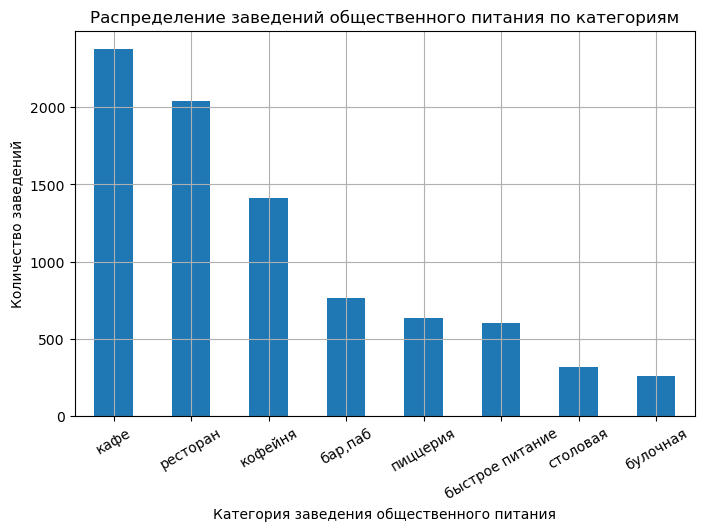

In [26]:
plt.figure(figsize=(8,5))

df['category'].value_counts().plot(
    kind = 'bar',
    rot = 30,
    legend = False,
    title = f'Распределение заведений общественного питания по категориям'
)
plt.xlabel('Категория заведения общественного питания')
plt.ylabel('Количество заведений')
plt.grid()
plt.show()

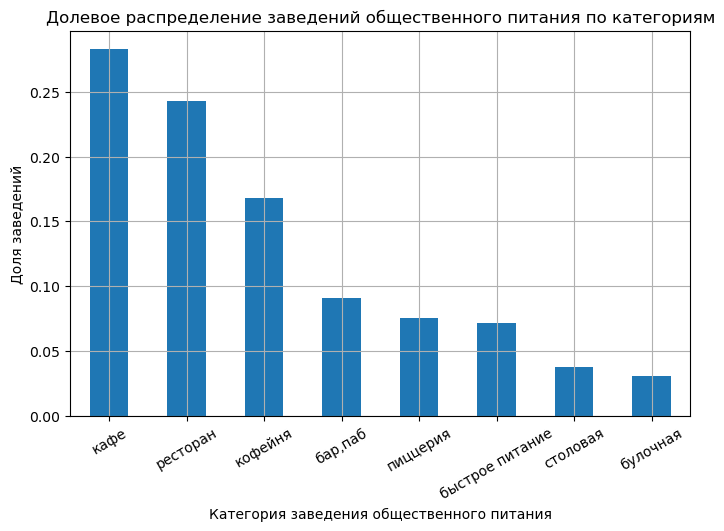

In [27]:
# Долевое распределение заведений общественного питания по категориям в долях
plt.figure(figsize=(8,5))

df['category'].value_counts(normalize=True).plot(
    kind = 'bar',
    rot = 30,
    legend = False,
    title = f'Долевое распределение заведений общественного питания по категориям'
)
plt.xlabel('Категория заведения общественного питания')
plt.ylabel('Доля заведений')
plt.grid()
plt.show()

---
Судя по распределению заведений можно сказать, что около 28% приходится на кафе, 24% рестараны - их больше всего. Менее 5% составляют столовые и булочные.

---

**Задача 2. Исследуем распределение количества заведений по административным районам Москвы, а также отдельно распределение заведений каждой категории в Центральном административном округе Москвы, чтобы определить, какие административные районы Москвы присутствуют в данных.**

---

In [28]:
# Расределение заведений общественного питания по административным районам Москвы
print(f'Количество объектов общественного питания в каждом административном районе Москвы:')
df['district'].value_counts()

Количество объектов общественного питания в каждом административном районе Москвы:


district
Центральный административный округ         2242
Северный административный округ             898
Южный административный округ                892
Северо-Восточный административный округ     890
Западный административный округ             850
Восточный административный округ            798
Юго-Восточный административный округ        714
Юго-Западный административный округ         709
Северо-Западный административный округ      409
Name: count, dtype: int64

---
Всего в данных представлено 9 администратиыных районов Москвы. Больше всего заведений в Центральном административном округе - 2242 шт. Меньше всего в Северо-Западном - 409 штук.

Построим визуализацию и наглядно посмотрим на распределение заведений в административных районах Москвы.

---

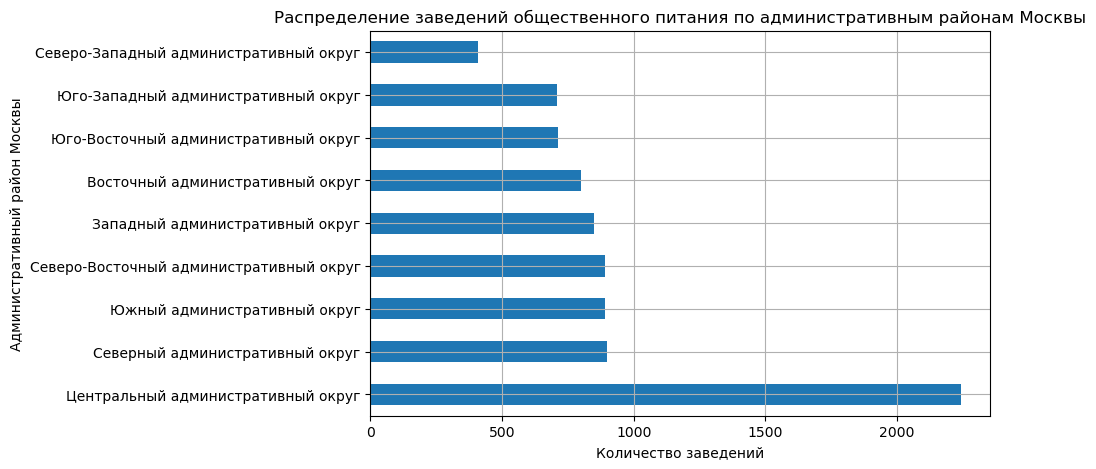

In [29]:
# Распределение заведений общественного питания по администранивным районам Москвы
plt.figure(figsize=(8,5))
df['district'].value_counts().plot(
    kind = 'barh',
    rot = 0,
    legend = False,
    title = f'Распределение заведений общественного питания по административным районам Москвы'
)
plt.xlabel('Количество заведений')
plt.ylabel('Административный район Москвы')
plt.grid()
plt.show()

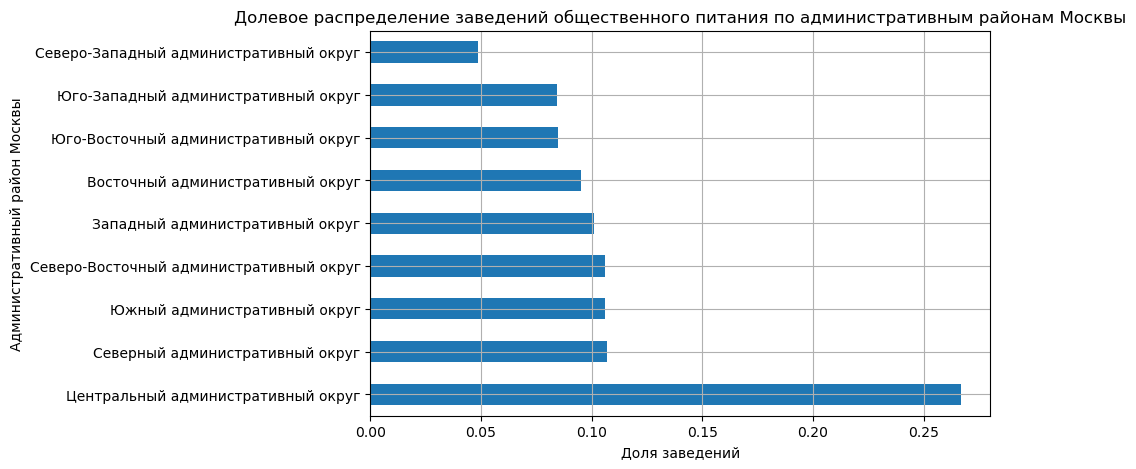

In [30]:
# Долеваое распределение заведений общественного питания по административным районам Москвы
plt.figure(figsize=(8,5))
df['district'].value_counts(normalize=True).plot(
    kind = 'barh',
    rot = 0,
    legend = False,
    title = f'Долевое распределение заведений общественного питания по административным районам Москвы'
)
plt.xlabel('Доля заведений')
plt.ylabel('Административный район Москвы')
plt.grid()
plt.show()

---
По распределению заведений общественного питания в административных района Москвы лидер Центральный АО, его доля составляет примерно 28% от общего количества заведений. Меньше всего заведений в Северо-Западном АО, доля составляет чуть меньше 5%.

---

Посмотрим распределение заведений каждой категории в Центральном АО.

---

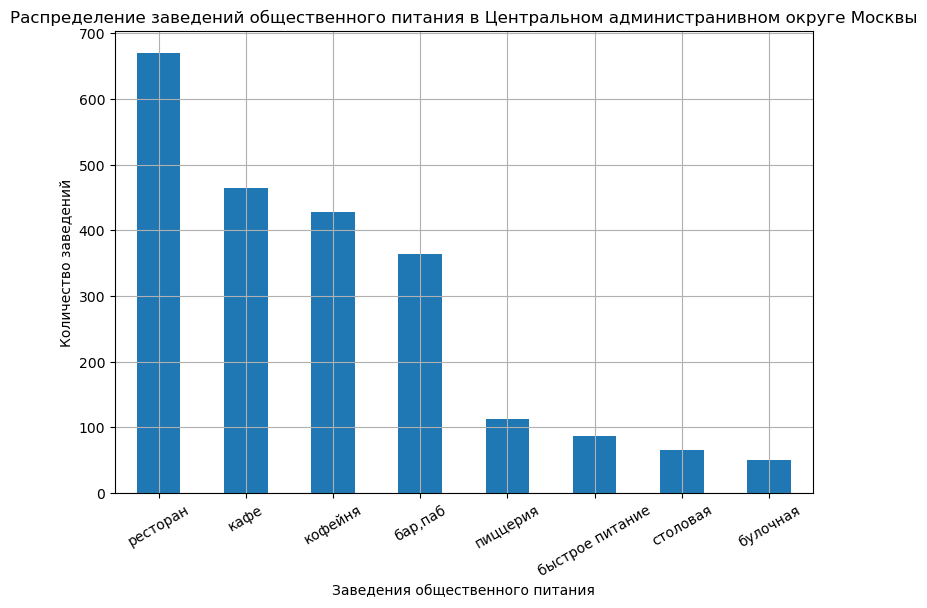

In [31]:
# Распределение заведений общественного питания в Центральном администранивном округе Москвы
df_cao = df[df['district'] == 'Центральный административный округ']
plt.figure(figsize=(9,6))
df_cao['category'].value_counts().plot(
    kind = 'bar',
    rot = 30,
    legend = False,
    title = f'Распределение заведений общественного питания в Центральном администранивном округе Москвы'
)
plt.xlabel('Заведения общественного питания')
plt.ylabel('Количество заведений')
plt.grid()
plt.show()

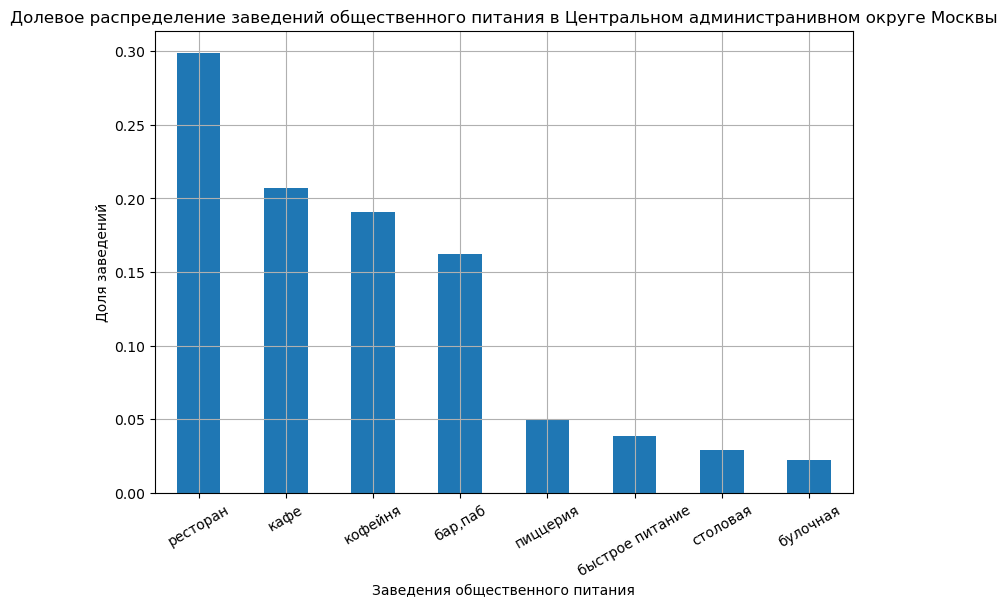

In [32]:
# Долевое распределение заведений общественного питания в Центральном администранивном округе Москвы
df_cao = df[df['district'] == 'Центральный административный округ']
plt.figure(figsize=(9,6))
df_cao['category'].value_counts(normalize=True).plot(
    kind = 'bar',
    rot = 30,
    legend = False,
    title = f'Долевое распределение заведений общественного питания в Центральном администранивном округе Москвы'
)
plt.xlabel('Заведения общественного питания')
plt.ylabel('Доля заведений')
plt.grid()
plt.show()

---
По диаграммам видно, что больше всего в Центральном АО ресторанов - около 670 шт., что составляет примерно 30% от общего числа заведений в ЦАО, а так же кафе - около 470 шт., что составляет примерно 21% от общего числа заведений.
Меньше 5% от общего числа заведений составляют заведения с категориями быстрое питание - около 90 шт., столовая - около 70шт. и булочная - около 50 шт.

---

**Задача 3. Изучим соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения, чтобы определить, каких заведений больше — сетевых или несетевых а так же какие категории заведений чаще являются сетевыми.**

---

In [33]:
# Проверяем соотношение сетевых и несетевых заведений по всем данным (0-не сетевые, 1- сетевые)
print(f'Соотношение сетевых и несетевых заведений общественного питания в административных районах Москвы')
print(df['chain'].value_counts(normalize=True))

Соотношение сетевых и несетевых заведений общественного питания в административных районах Москвы
chain
0    0.618781
1    0.381219
Name: proportion, dtype: float64


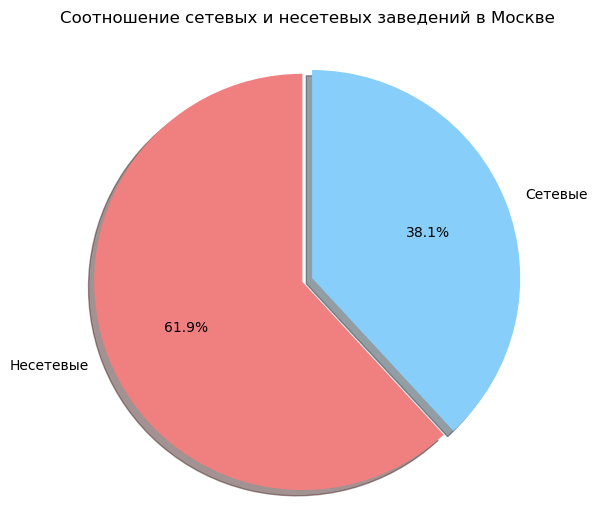

In [34]:
chain_counts = df['chain'].value_counts(normalize=True)

# Подписи для секторов (0 - несетевые, 1 - сетевые)
labels = ['Несетевые', 'Сетевые']

# Цвета
colors = ['lightcoral', 'lightskyblue']

# Строим круговую диаграмму
plt.figure(figsize=(6, 6))
plt.pie(
    chain_counts,
    labels=labels,
    autopct='%1.1f%%',  
    startangle=90,      
    colors=colors,
    shadow=True,        
    explode=(0.05, 0) 
)

plt.title('Соотношение сетевых и несетевых заведений в Москве', pad=20)
plt.axis('equal')
plt.show()

---
Несетевые заведения общественного питания преобладают и составляют около 61% от общего числа заведений.

---

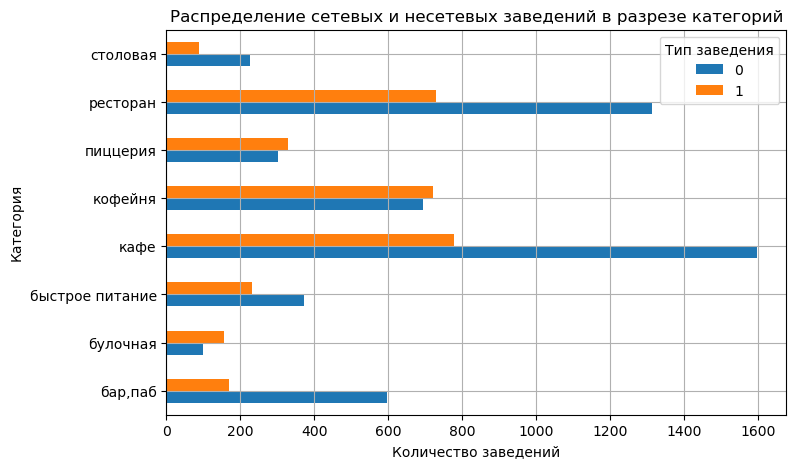

In [35]:
# Распределение сетевых и несетевых заведений в разрезе категорий
grouped = df.groupby('category')['chain'].value_counts().unstack(fill_value = 0)
grouped.plot(
    kind = 'barh',
    title = f'Распределение сетевых и несетевых заведений в разрезе категорий',
    ylabel = 'Категория',
    xlabel = 'Количество заведений',
    rot = 0,
    figsize = (8,5))

plt.legend(title='Тип заведения')
plt.grid()
plt.show()

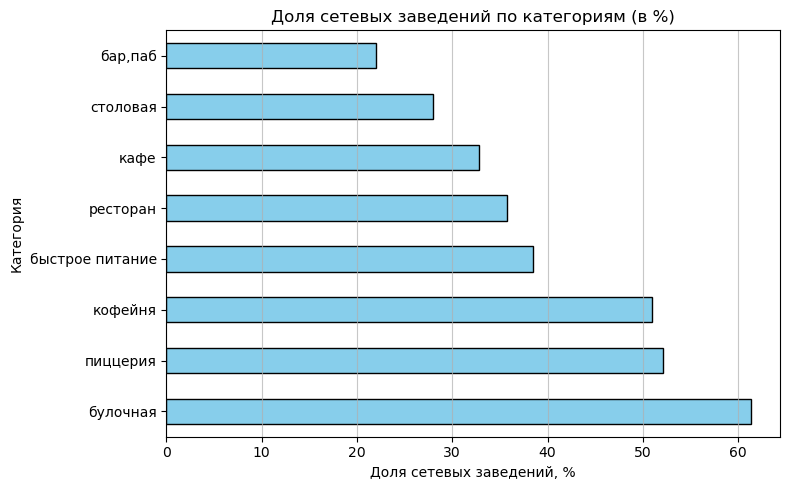

In [36]:
# Рассчитываем долю сетевых заведений по категориям
grouped = df.groupby('category')['chain'].mean().sort_values(ascending=False) * 100

# Строим горизонтальную столбчатую диаграмму
plt.figure(figsize=(8, 5))
grouped.plot(
    kind='barh',
    title='Доля сетевых заведений по категориям (в %)',
    xlabel='Доля сетевых заведений, %',
    ylabel='Категория',
    color='skyblue',
    edgecolor='black'
)

plt.grid(axis='x', alpha=0.7)
plt.tight_layout()
plt.show()

---
Среди заведение общественного питания преобладают несетевые кафе - около 1300 шт. и рестораны - около 1250 шт. 

Сетевыми чаще всего являются булочные - около 61%, пиццерии - около 52% и кафе - около 51% 

---

**Задача 4. Исследуем количество посадочных мест в заведениях, чтобы определить, встречаются ли в данных аномальные значения или выбросы. Если да, то с чем они могут быть связаны? Приведем для каждой категории заведений наиболее типичное для него количество посадочных мест.**

---

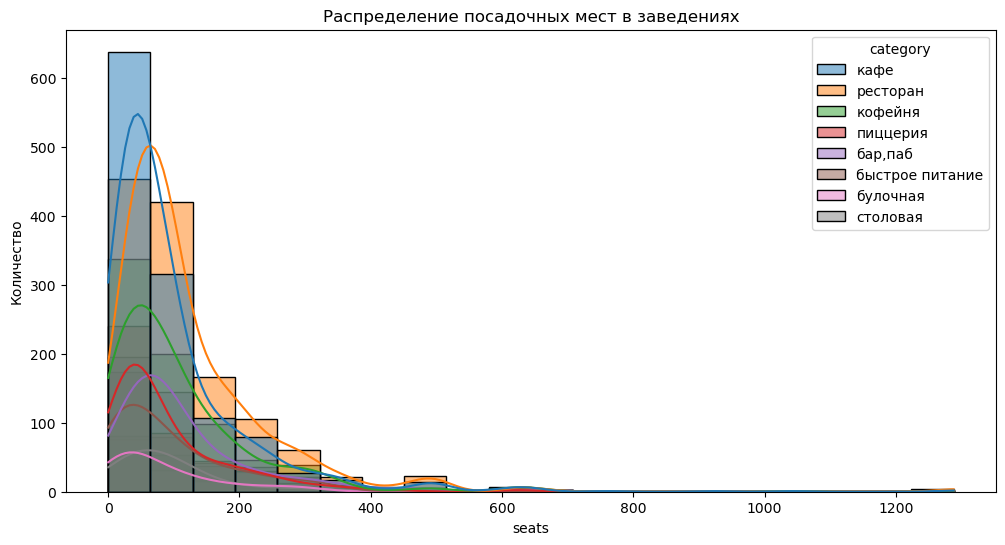

In [37]:
# Построим гистограмму и посмотрим количество посадочных мест в заведениях по категориям
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='seats', bins=20,kde=True, hue = 'category')
plt.title(f'Распределение посадочных мест в заведениях')
plt.ylabel('Количество')
plt.show()

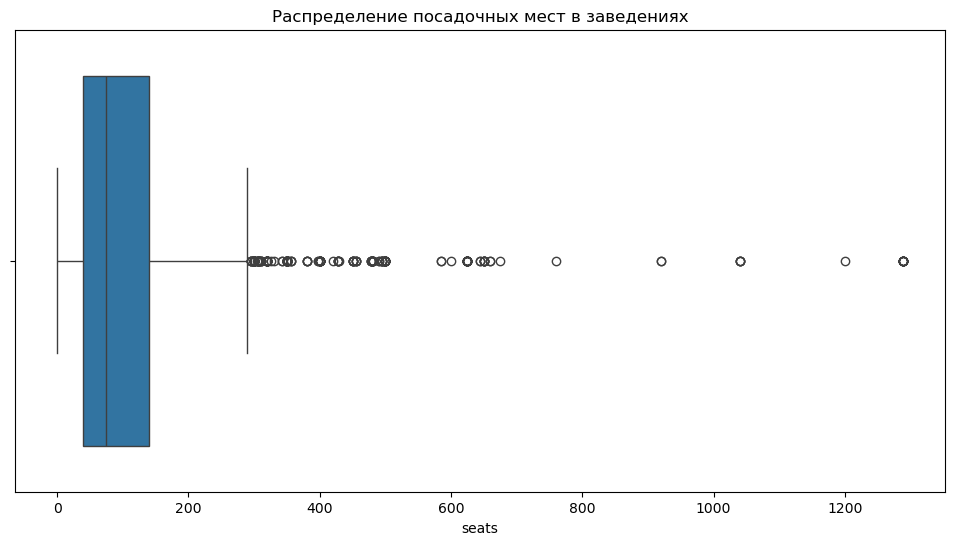

In [38]:
# Построим диаграмму размаха и посмотрим выбросы по количеству посадочных мест
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x = 'seats')
plt.title(f'Распределение посадочных мест в заведениях')
plt.show()

---
На гистограмме и диаграмме размаха наблюдается смещение данных влево и выбросы в данных, превышающих значение около 300.

Дополним диаграмму размаха и сгруппируем данные по категории заведения.

---

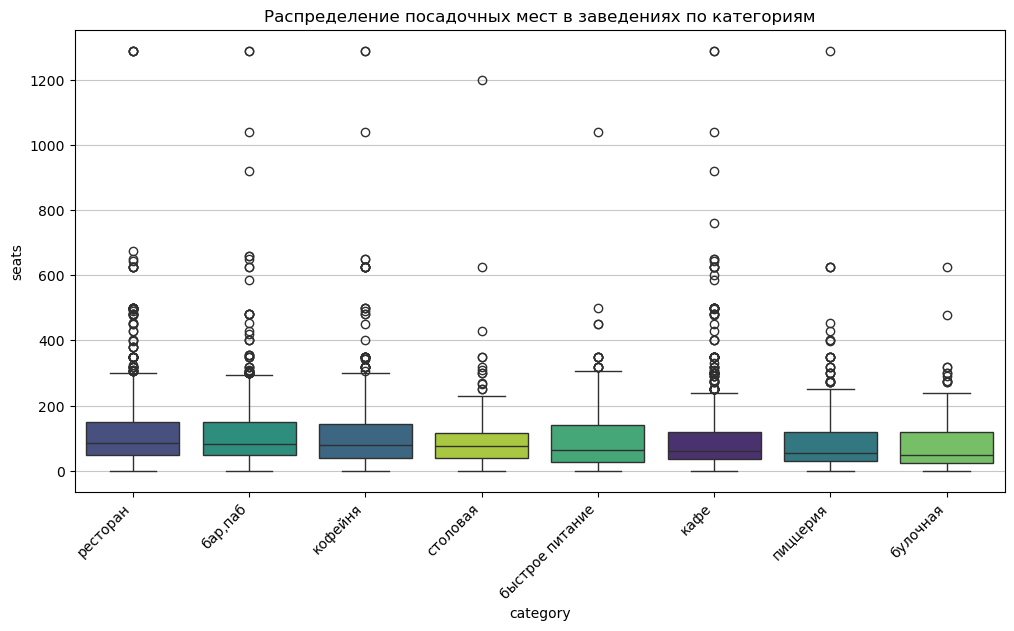

In [39]:
# Диаграмма размаха распределения пасадочных мест в заведениях по категориям (отсортированная)
plt.figure(figsize=(12, 6))
# Сортируем категории по медиане количества мест
order = df.groupby('category')['seats'].median().sort_values(ascending=False).index
# Строим boxplot с сортировкой
sns.boxplot(
    data=df,
    y='seats',
    x='category',
    order=order,
    palette='viridis',
    hue='category'
)

plt.title('Распределение посадочных мест в заведениях по категориям')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.7)
plt.show()

---
Действительно, во всех категориях наблюдаются высокие значения, то есть выбросы. Возможно это связано с некорректными данными или спецификой заведения (проведение каких-либо банкетных мероприятий, квизов и т.д.).

Отфильтруем данные, убрав из визуализации выбросы.

---

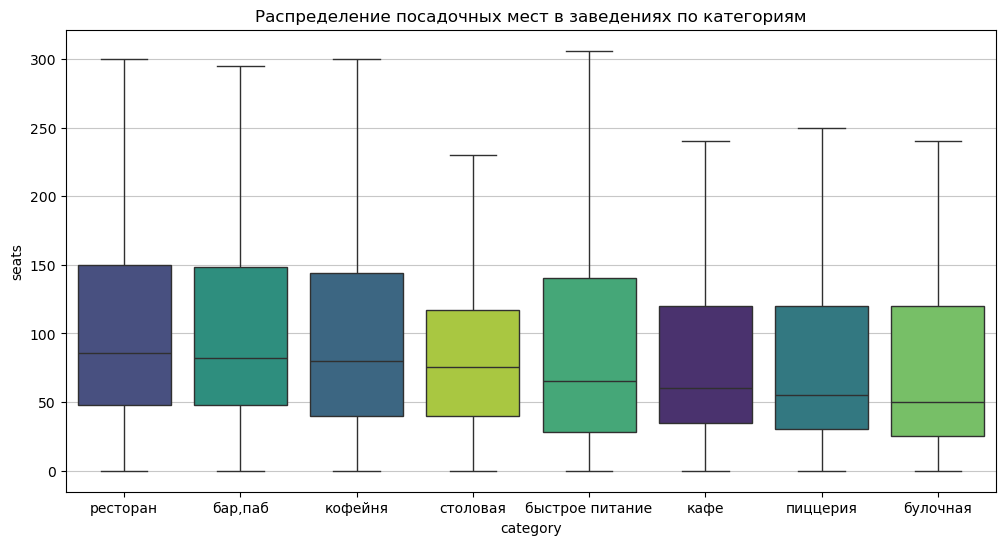

In [40]:
# Отфильтруем датасет и построим еще раз диаграмму размаха без выбросов и аномальных значений
plt.figure(figsize=(12, 6))
# Сортируем категории по медиане количества мест
order = df.groupby('category')['seats'].median().sort_values(ascending=False).index
sns.boxplot(
    data=df,
    y = 'seats', 
    x = 'category',
    order=order,
    palette='viridis',
    hue='category',
    showfliers=False)
plt.grid(axis='y', alpha=0.7)
plt.title(f'Распределение посадочных мест в заведениях по категориям')
plt.show()

---
Теперь можно для каждой категории заведения посчитать медианное значение, которое будет свидетельствовать о типичном для него количество посадочных мест.

---

In [41]:
# Составляем сгруппированную по категории таблицу и высчитываем медиану посадочных мест
median_seats = df.groupby('category')['seats'].median().reset_index()
median_seats

,category,seats
0,"бар,паб",82.0
1,булочная,50.0
2,быстрое питание,65.0
3,кафе,60.0
4,кофейня,80.0
5,пиццерия,55.0
6,ресторан,86.0
7,столовая,75.5


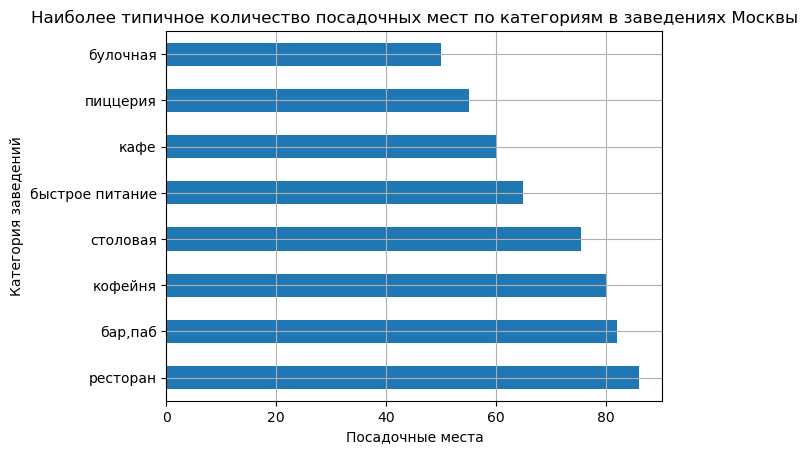

In [42]:
# Строим линейчатую диаграмму с сортировкой медианных значений
median_seats.sort_values(by='seats', ascending=False).plot(
    kind = 'barh',
    x = 'category',
    y = 'seats',
    legend = False
)
plt.grid()
plt.ylabel('Категория заведений')
plt.xlabel('Посадочные места')
plt.title('Наиболее типичное количество посадочных мест по категориям в заведениях Москвы')
plt.show()

---
Теперь видно, что наиболее типичное количество посадочных мест в заведениях Москвы следующее:
- ресторан - 86
- бар,паб - 82
- кофейня - 80
- столовая - около 75
- быстрое питание - около 65
- кафе - 60
- пиццерия - 55
- булочная - 50

---

**Задача 5. Исследуем рейтинг заведений и определим, сильно ли различаются усреднённые рейтинги для разных типов общепита.**

---

In [43]:
# Составляем сгруппированную по категории таблицу и высчитываем средний рейтинг
mean_rating = df.groupby('category')['rating'].mean().reset_index()
mean_rating

,category,rating
0,"бар,паб",4.387696
1,булочная,4.268359
2,быстрое питание,4.050249
3,кафе,4.124284
4,кофейня,4.277282
5,пиццерия,4.301264
6,ресторан,4.290401
7,столовая,4.211429


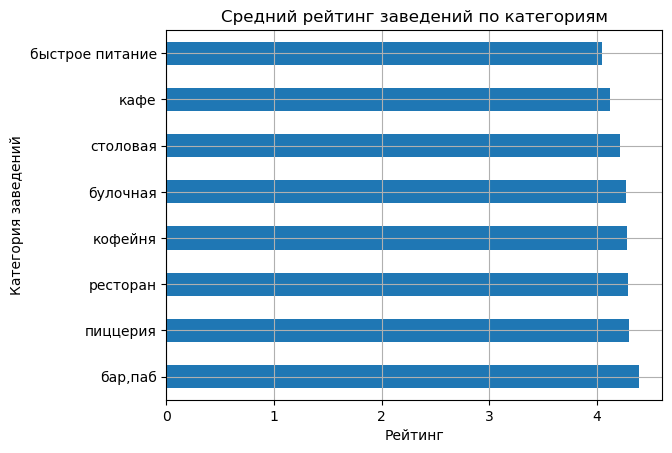

In [44]:
# Строим линейчатую диаграмму с сортировкой средних значений рейтинга
mean_rating.sort_values(by='rating', ascending=False).plot(
    kind = 'barh',
    x = 'category',
    y = 'rating',
    legend = False
)
plt.grid()
plt.ylabel('Категория заведений')
plt.xlabel('Рейтинг')
plt.title('Средний рейтинг заведений по категориям')
plt.show()

---
Средний рейтинг заведений общественного питания по всем категориям не ниже 4, однако можно выделить, что чуть лучше рейтинг у категорий бар,паб - 4.4, пиццерии - 4.3 и ресторана - 4.3.

---

**Задача 6. Изучим, с какими данными показывают самую сильную корреляцию рейтинги заведений. Построим и визуализируем матрицу корреляции рейтинга заведения с разными данными: его категория, положение (административный район Москвы), статус сетевого заведения, количество мест, ценовая категория и признак, является ли заведения круглосуточным. Выберем самую сильную связь и проверим её.**

---

In [45]:
# Вычисляем корреляционную матрицу с использованием phi_k
correlation_matrix = df[['category', 'district', 'chain', 'seats', 'price',
                         'is_24_7', 'rating']].phik_matrix()

# Выводим результат
print('Корреляционная матрица с коэффициентом phi_k для переменной rating')
correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)

interval columns not set, guessing: ['chain', 'seats', 'rating']
Корреляционная матрица с коэффициентом phi_k для переменной rating


,rating
price,0.262056
category,0.198739
district,0.189453
is_24_7,0.161010
chain,0.118857
seats,0.000000


---
Визуализируем результат корреляции с помощью тепловой карты и библиотеки seaborn.

---

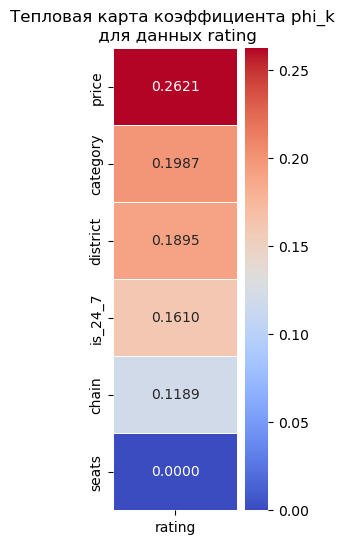

In [46]:
# Строим тепловую карту
plt.figure(figsize=(2, 6))

# Сохраняем матрицу корреляции признака rating с другими признаками клиента
data_heatmap = correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)
sns.heatmap(data_heatmap,
            annot=True, # Отображаем численные значения в ячейках карты
            fmt='.4f', # Форматируем значения корреляции: 4 знака после точки
            cmap='coolwarm', # Устанавливаем цветовую гамму от красного (макс. значение) к синему
            linewidths=0.5, # Форматируем линию между ячейками карты
            cbar=True
           )

plt.title('Тепловая карта коэффициента phi_k \n для данных rating')
plt.show()

---
На тепловой карте по всем данным мы видим слабую корреляцию, взаимосвязи практически нет. Наибольшую корреляцию (0.26) показывает ценовая категория - предполагает, что дорогие заведения чаще получают высокие оценки. Это может быть связано с качеством обслуживания, интерьером или кухней.
Категория и круглосуточность имеют схожую силу влияния (~0.19) - рестораны могут иметь более высокие рейтинги, чем фастфуд.
Круглосуточные заведения часто ориентированы на удобство, что ценится клиентами.
Слабая корреляция (0.12) с сетевыми заведениями указывает, что сетевой статус почти не влияет на оценку. Возможно, клиенты ценят уникальность так же, как и стабильность сетей.
Посадочные места (seats) - нулевая корреляция: размер заведения (количество мест) не связан с рейтингом.

Самая сильная связь с данными ценовой категории - проверим.

---

In [47]:
# Создадим датафрейм с количеством оценок в каждой ценовой категории
df_count_rating = df.groupby('price')['rating'].agg('count').reset_index()
df_count_rating

,price,rating
0,высокие,478
1,выше среднего,564
2,низкие,156
3,средние,2117


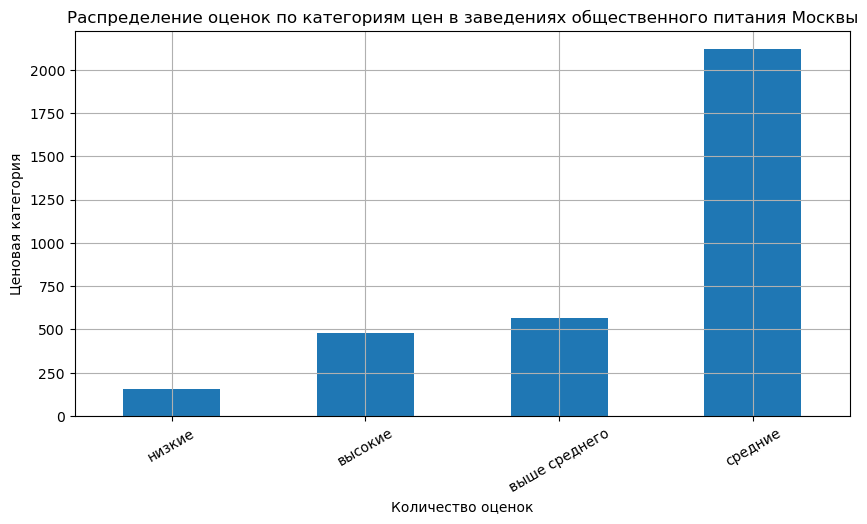

In [48]:
# Построим столбчатую диаграмму
df_count_rating.sort_values(by='rating', ascending = True).plot(
    kind = 'bar',
    x = 'price',
    y = 'rating',
    rot = 30,
    legend = False,
    figsize = (10,5)
)

plt.title(f'Распределение оценок по категориям цен в заведениях общественного питания Москвы')
plt.xlabel('Количество оценок')
plt.ylabel('Ценовая категория')
plt.grid()
plt.show()

---
На диаграмме видно, что большинство оценок (2117) у заведений со средней ценовой категорией. Рассчитаем средний рейтинг для каждой ценовой категории и сравним со средним рейтингом

---

In [49]:
# Создадим датафрейм со средним рейтингом в каждой ценовой категории
df_mean_rating = df.groupby('price')['rating'].agg('mean').reset_index()
df_mean_rating

,price,rating
0,высокие,4.436611
1,выше среднего,4.386347
2,низкие,4.173077
3,средние,4.297874


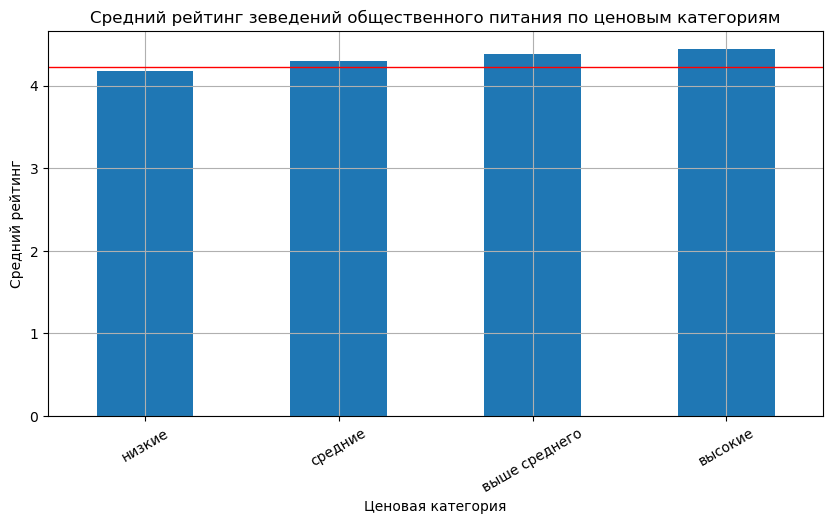

In [50]:
# Построим столбчатую диаграмму
df_mean_rating.sort_values(by='rating', ascending = True).plot(
    kind = 'bar',
    x = 'price',
    y = 'rating',
    rot = 30,
    legend = False,
    figsize = (10,5)
)
# Расчитаем общий средний рейтинг заведений
mean_rating = df['rating'].mean()

# Нанесем линию среднего рейтинга на диаграмму
plt.axhline(mean_rating,
            color = 'red',
            linestyle = '-',
            linewidth = 1,
            label = f'Средний рейтинг заведений {round(mean_rating,3)}')

plt.title(f'Средний рейтинг зеведений общественного питания по ценовым категориям')
plt.xlabel('Ценовая категория')
plt.ylabel('Средний рейтинг')
plt.grid()
plt.show()

---
Самый высокий рейтинг у заведений с высокой ценовой категорией - примерно 4.44. 

Из полученных данных можно сделать вывод, что охотнее всего оценку заведениям оставляют посетители в заведениях средней ценовой категории. Оценки по всем категориям практически одинаковые.

Делаем вывод, что рейтинг заведения никак не коррелирует с ценовой категорией.

---

**Задача 7. Сгруппируем данные по названиям заведений и найдем топ-15 популярных сетей в Москве, то есть с большим количеством заведений этой сети в регионе. Для них посчитаем значение среднего рейтинга. Определим к какой категории заведений они относятся.**

---

In [51]:
# Отсортирует заведения и оставим только сетевые
df_chain = df[df['chain'] == 1]
# Сгруппируем заведения по назвнию и категории и посчитаем количество заведений и средний рейтинг
df_chain = df_chain.groupby(['name', 'category']).agg(
    name_count = ('name', 'count'),
    mean_rating = ('rating', 'mean')
).sort_values('name_count', ascending = False).reset_index()
# Выведем ТОП-15
top_15 = round(df_chain.head(15),2)
top_15

,name,category,name_count,mean_rating
0,ШОКОЛАДНИЦА,кофейня,119,4.18
1,ДОМИНО'С ПИЦЦА,пиццерия,76,4.17
2,ДОДО ПИЦЦА,пиццерия,74,4.29
3,ONE PRICE COFFEE,кофейня,71,4.06
4,ЯНДЕКС ЛАВКА,ресторан,69,3.87
5,COFIX,кофейня,65,4.08
6,PRIME,ресторан,49,4.11
7,КОФЕПОРТ,кофейня,42,4.15
8,КУЛИНАРНАЯ ЛАВКА БРАТЬЕВ КАРАВАЕВЫХ,кафе,39,4.39
9,ТЕРЕМОК,ресторан,36,4.11


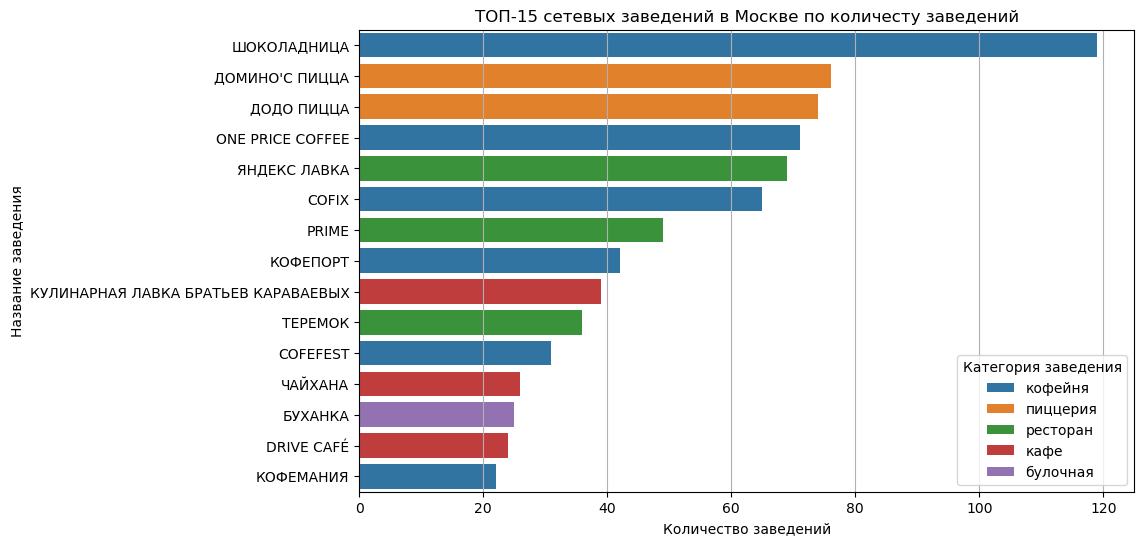

In [52]:
# Строим столбчатую диаграмму для отображение ТОП-15 сетевых заведений в Москве по количесту 
plt.figure(figsize=(10, 6))
sns.barplot(
    data = top_15,
    x = 'name_count',
    y = 'name',
    hue = 'category'
)
plt.title(f'ТОП-15 сетевых заведений в Москве по количесту заведений')
plt.xlabel(f'Количество заведений')
plt.ylabel(f'Название заведения')
plt.legend(title = 'Категория заведения')
plt.grid(axis='x')
plt.show()

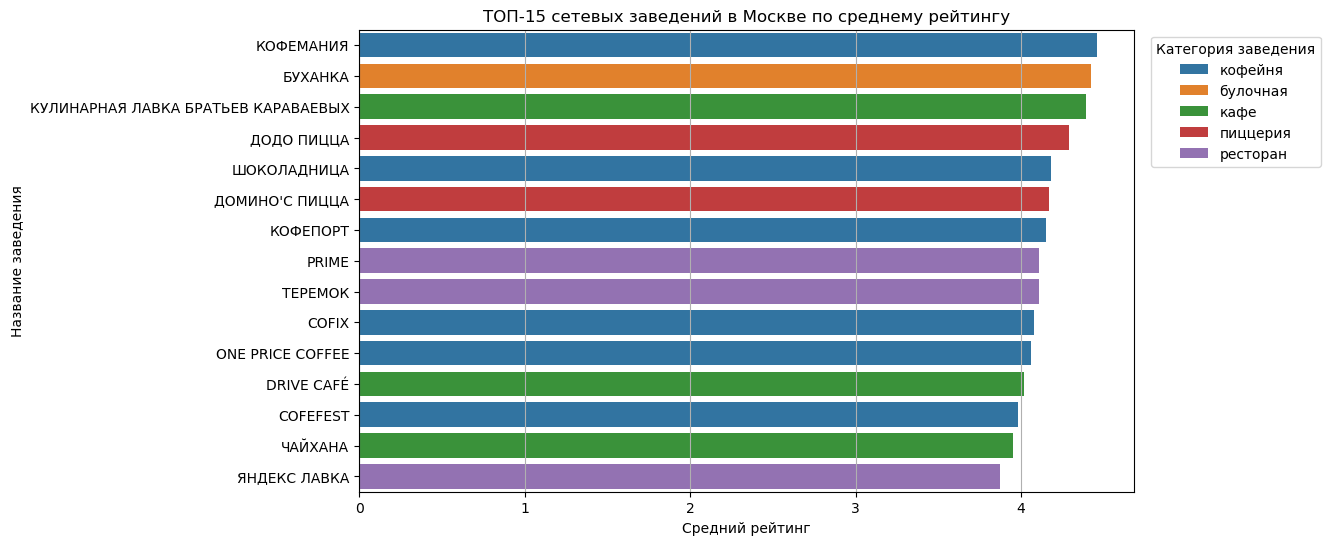

In [53]:
# Строим столбчатую диаграмму для отображение ТОП-15 сетевых заведений в Москве по седнему рейтингу 
plt.figure(figsize=(10, 6))
top_15_sorted = top_15.sort_values('mean_rating', ascending=False) # Отсортировала рейтинг
sns.barplot(
    data = top_15_sorted,
    x = 'mean_rating',
    y = 'name',
    hue = 'category'
)
plt.title(f'ТОП-15 сетевых заведений в Москве по среднему рейтингу')
plt.xlabel(f'Средний рейтинг')
plt.ylabel(f'Название заведения')
plt.legend(title='Категория заведения', bbox_to_anchor=(1.25, 1), loc='upper right') # Вынесла легенду за пределы диаграммы
plt.grid(axis='x')
plt.show()

---
Среди полученных данных видим, что самое популярное заведение по кличеству, это сеть кофеен Шоколадница (119 шт.). Далее идут две сетевые пиццерии: Доминос пицца и Додо пицца (76 шт. и 74шт.). По среднему рейтингу на первом месте кофейня Кофемания (4.46), далее идет булочная Буханка (4.42) и кафе Братьев Короваевых (4.39).

На последем месте по количеству заведений и рейтингу заведение быстрого питания Крошка Картошка (20 заведений, рейтинг 3.72).

---

**Задача 8. Изучим вариацию среднего чека заведения (столбец `middle_avg_bill`) в зависимости от района Москвы. Проанализируем цены в Центральном административном округе и других. Посмотрим, как удалённость от центра влияет на цены в заведениях.**

---

Столбец `middle_avg_bill` содержит 62,5% пропусков, поэтому для корректного результата необходимо отфильтровать датафрейм.

In [54]:
# Создадим отфильтрованный датафрейм среднего чека заведения
df_middle_avg_bill = df[df['middle_avg_bill'] > 0]
# Выведем статистическую информацию 
df_middle_avg_bill['middle_avg_bill'].describe()

count     3148.000000
mean       958.358032
std       1009.748169
min         30.000000
25%        375.000000
50%        750.000000
75%       1250.000000
max      35000.000000
Name: middle_avg_bill, dtype: float64

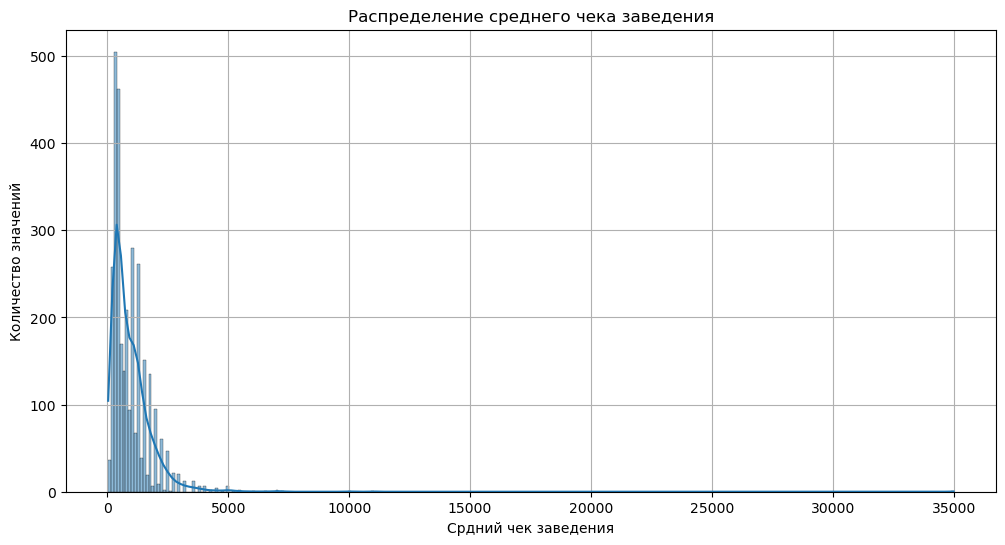

In [55]:
# Построим гистограмму распределения среднего чека заведения
plt.figure(figsize=(12, 6))
sns.histplot(
    data = df_middle_avg_bill,
    x = 'middle_avg_bill',
    kde = True
)
plt.title('Распределение среднего чека заведения')
plt.xlabel('Срдний чек заведения')
plt.ylabel('Количество значений')
plt.grid()
plt.show()

---
Статистические данные демонстрируют правостороннее распределение, характерное для ценовых показателей. Это означает:
- Большое количество бюджетных вариантов
- Постепенное уменьшение количества заведений по мере роста цен
- Несколько экстремально дорогих "выбросов".

Однако экстремальные значения (до 35 000 руб.) требуют проверки:
- Возможны ошибки данных
- Или действительно есть единичные премиальные заведения

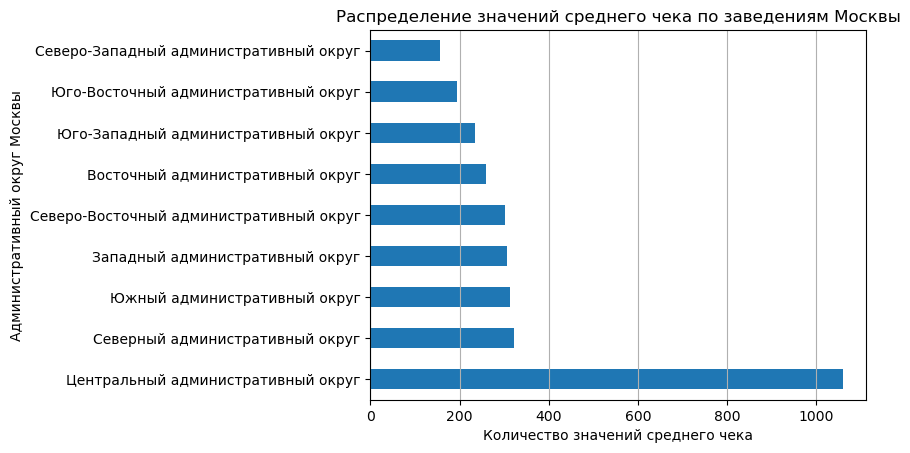

In [56]:
# Построим столбчатую диаграмму и посмотрим распределение значений по округам Москвы
df_middle_avg_bill['district'].value_counts().plot(
    kind = 'barh',
    legend = False,
    title = f'Распределение значений среднего чека по заведениям Москвы'
)
plt.xlabel('Количество значений среднего чека')
plt.ylabel('Административный округ Москвы')
plt.grid(axis='x')
plt.show()

In [57]:
print('Распределение значений среднего чека по заведениям Москвы:')
df_middle_avg_bill['district'].value_counts()

Распределение значений среднего чека по заведениям Москвы:


district
Центральный административный округ         1059
Северный административный округ             322
Южный административный округ                314
Западный административный округ             306
Северо-Восточный административный округ     301
Восточный административный округ            260
Юго-Западный административный округ         235
Юго-Восточный административный округ        194
Северо-Западный административный округ      157
Name: count, dtype: int64

---
Большинство значений среднего чека оносятся к Центральному АО Москвы - 1059. Меньше всего данных в Северо-Западном АО - 157.

Посмотрим на среднее значение среднего чека по районам Москвы.

---

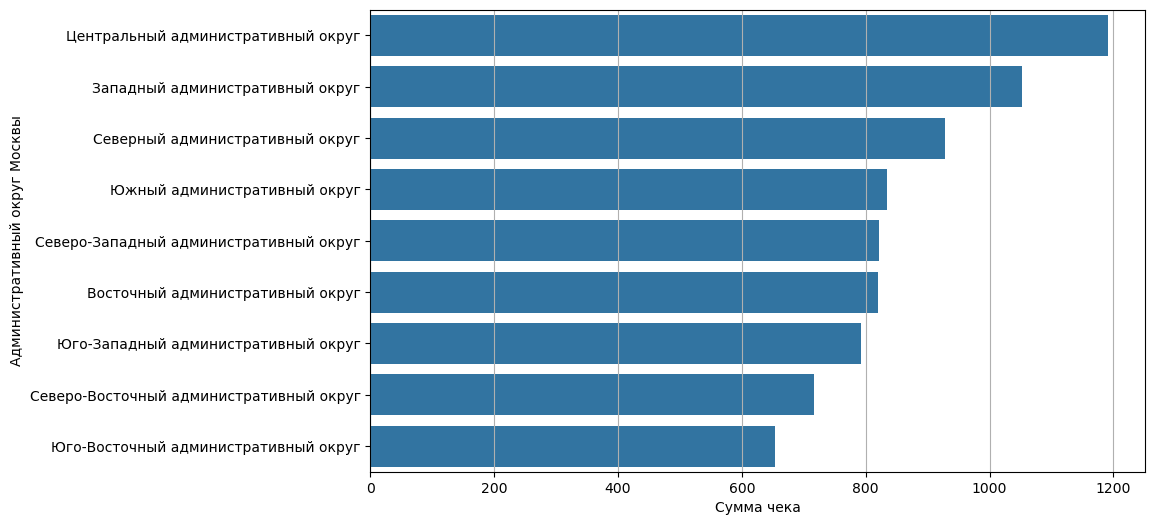

In [58]:
df_middle_avg_bill_mean = df_middle_avg_bill.groupby('district').agg(
    middle_avg_bill_mean=('middle_avg_bill', 'mean')
).sort_values('middle_avg_bill_mean', ascending=False).reset_index()

# Построим столбчатую диаграмму и посмотрим среднее значение по округам Москвы
plt.figure(figsize=(10, 6))
sns.barplot(
    data = df_middle_avg_bill_mean,
    x = 'middle_avg_bill_mean',
    y = 'district',
)
plt.title = ('Cреднее значение среднего чека по заведениям Москвы')
plt.xlabel('Сумма чека')
plt.ylabel('Административный округ Москвы')
plt.grid(axis='x')
plt.show()

In [59]:
print('Среднее значение среднего чека по заведениям Москвы:')
round(df_middle_avg_bill_mean,2)

Среднее значение среднего чека по заведениям Москвы:


,district,middle_avg_bill_mean
0,Центральный административный округ,1192.180054
1,Западный административный округ,1053.229980
2,Северный административный округ,927.960022
3,Южный административный округ,834.400024
4,Северо-Западный административный округ,822.219971
5,Восточный административный округ,820.630005
6,Юго-Западный административный округ,792.559998
7,Северо-Восточный административный округ,716.609985
8,Юго-Восточный административный округ,654.099976


---

### Промежуточный вывод

Анализ данных заведений общественного питания Москвы показал:
- Среди категорий заведений преобладают кафе 28% и рестораны 24%. Менее 5% от общего количества заведений составляют столовая и булочная.
- Больше всего заведений общественного питания приходятся на Центральный административный округ (28%), меньше всего Северо-Западный (менее 5%). В Центральном АО больше всего располагается ресторанов (30%) и кафе (21%). Меньше всего булочных, столовых и заведений быстрого питания (менее 5%).
- Несетевые заведения общественного питания преобладают и составляют около 61% от общего количества. Среди несетевых заведений больше всего кафе (около 1300) и ресторанов (около1250). Сетевыми заведениями чаще всего являются булочные – около 61%, пиццерии – около 52% и кафе – около 51%.
- Наиболее типичное количество посадочных мест в заведениях:
    - ресторан - 86
    - бар,паб - 82
    - кофейня - 80
    - столовая - около 75
    - быстрое питание - около 65
    - кафе - 60
    - пиццерия - 55
    - булочная - 50
- Средний рейтинг заведений общественного питания по всем категориям примерно одинаковый и не опускается ниже 4, однако чуть лучше рейтинг у категорий бар,паб – 4.4, пиццерии – 4.3 и ресторана – 4.3.
- Представленные данные никак между собой не коррелируются.
- Выявлены наиболее популярные сетевые заведения, это Шоколадница – 119, Доминос Пицца – 76 и Додо пицца – 74.
- При изучении данных по среднему чеку в заведении выявлено, что выше всего чек в Центральном АО, а самый низкий в Юго-Восточном АО.

---

## 4. Итоговый вывод и рекомендации

По заказу инвесторов из фонда провели исследовательский анализ заведений общественного питания Москвы, составленный на основе данных на лето 2022 года. Данные включали информацию о заведениях и среднем чеке в них. Акцент исследования был на том, чтобы определить распределение заведений по округам Москвы, их рейтинги, средний чек, чтобы инвесторы могли определиться с подходящим местом и категорией заведения. 

### Основные задачи, которые стояли перед нами
- Загрузить данные и познакомиться с их содержимым.
- Провести предобработку данных.
- Провести исследовательский анализ данных:
    - изучить данные более детально;
    - изучить взаимосвязь данных между собой.
- Сформулировать выводы по проведённому анализу.

Предоставленные данные хорошего качества, названия столбцов указаны в едином регистре и не требуют преобразования, значения в столбцах соответствуют своему описанию, тип данных определен верно. 
В некоторых столбцах оптимизировали размерность типов данных. 

Изучены пропуски в данных. Пропуски были обнаружены в столбцах:
- `hours` в количестве 536 штук, что составляет 6% данных столбца. Пропуски оставлены, чтобы не потерять данные из других столбоц, необохдимые для анализа.
- `seats` (43% данных), `price` (60% данных), `avg_bill` (54% данных), `middle_avg_bill` (62% данных) и `middle_coffee_cup` (93% данных).
Выявлены и удалены неявные дубликаты по названию заведения и адресу в количестве 4 штук. Неявные дубликаты не обнаружены.
Создан столбец-признак `is_24_7`, который указывает работает ли заведение ежедневно и круглосуточно или нет.

### Исследовательский анализ данных

Был проведен исследовательский анализ данных, даны ответы на 8 поставленных вопросов. Все исследования подкреплены визуализациями.

Анализ данных заведений общественного питания Москвы показал:

- Среди категорий заведений преобладают кафе 28% и рестораны 24%. Менее 5% от общего количества заведений составляют столовая и булочная.
- Больше всего заведений общественного питания приходятся на Центральный административный округ (28%), меньше всего Северо-Западный (менее 5%). В Центральном АО больше всего располагается ресторанов (30%) и кафе (21%). Меньше всего булочных, столовых и заведений быстрого питания (менее 5%).
- Несетевые заведения общественного питания преобладают и составляют около 61% от общего количества. Среди несетевых заведений больше всего кафе (около 1300) и ресторанов (около1250). булочные – около 61%, пиццерии – около 52% и кафе – около 51%..
- Наиболее типичное количество посадочных мест в заведениях:
    -ресторан - 86
    -бар,паб - 82
    -кофейня - 80
    -столовая - около 75
    -быстрое питание - около 65
    -кафе - 60
    -пиццерия - 55
    -булочная - 50
- Средний рейтинг заведений общественного питания по всем категориям примерно одинаковый и не опускается ниже 4, однако чуть лучше рейтинг у категорий бар,паб – 4.4, пиццерии – 4.3 и ресторана – 4.3.
- Представленные данные никак между собой не коррелируются.
- При изучении данных по среднему чеку в заведении выявлено, что выше всего чек в Центральном АО, а самый низкий в Юго-Восточном АО.

### Рекомендации

Приоритетные локации для инвестиций
`Центральный АО`: высокий средний чек (1192 руб.) + максимальная концентрация заведений.
Рекомендация: Открывать премиальные форматы (рестораны, лаунж-бары) с уникальной концепцией.
Риск: Высокая конкуренция

`Западный и Северный АО`: высокий баланс среднего чека (1053 и 927 руб.) и количество заведений.
Рекомендация: Сетевые проекты (кафе/кофейни среднего ценового сегмента).

`Юго-Восточный АО`: минимальный чек (654 руб.) + мало заведений, соответственно низкий входной барьер.
Рекомендация: Бюджетные форматы (фуд-корты, пекарни с демократичными ценами).

Оптимальные категории заведений
- Рестораны/бары:
Высокий рейтинг (4.3–4.4) + большой средний чек в ЦАО.
Акцент: Сделать ставку на тематические концепции (например, авторская кухня или крафтовые напитки).
- Кафе/кофейни:
Лидеры по количеству (28% рынка) + стабильный спрос.
Совет: В нецентральных округах — сетевые проекты с единым стандартом качества.
- Булочные/столовые:
Меньше 5% рынка, хороший потенциал для нишевых проектов (например, экопекарни или столовые с фермерскими продуктами).


Для премиум-сегмента: учитывать, что в Центральном АО 75% заведений имеют чек до 1250 руб. - выделяться нужно через сервис и атмосферу.

Для бюджетного сегмента: в Юго-Восточном АО средний чек в 2 раза ниже, чем в центре - важно контролировать себестоимость.

Дополнительные исследования
- Анализ аудитории:
    - изучить демографию (например, в ЦАО больше туристов, в спальных районах — местных жителей).
    - запустить опросы о предпочтениях (что важно: цена, скорость обслуживания, качество еды).
- Маркетинговые стратегии:
    - в дорогих округах — делать упор на эксклюзивность (например, дегустационные меню).
    - в бюджетных — на акции (комбо-обеды, программы лояльности).

Операционные рекомендации
Посадочные места:
Оптимальное количество: 60–80 (кафе/кофейни) и 80+ (рестораны).
Важно: В небольших заведениях (булочные) — делать ставку на вынос.

Круглосуточные заведения:
Столбец `is_24_7` показал, что таких заведений мало - можно занять эту нишу в транспортных хабах (вокзалы, аэропорты).

Итоговый совет инвесторам:
"Золотая середина" — сетевые кофейни/кафе среднего ценового сегмента в Северном/Западном АО:
- умеренная конкуренция
- платёжеспособная аудитория
- возможность масштабирования